In [5]:
import sys
print(sys.executable)

e:\Smart-Irrigation-Project\ML-model\models\sensor-models\mlp\tf-env\Scripts\python.exe


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from dotenv import load_dotenv
import os
from pathlib import Path

In [7]:
df = pd.read_csv('../../../data/sensor_data/train.csv')

print(df.head(3).to_string())
print('\n--- DTYPES ---')
print(df.dtypes)
print('\n--- TARGET ---')
print(df['besoin_eau'].value_counts())

   Soil_pH  Soil_Moisture  Organic_Carbon  Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  Sunlight_Hours  Wind_Speed_kmh  Field_Area_hectare  Previous_Irrigation_mm  Soil_Type  Crop_Type  Crop_Growth_Stage  Season  Mulching_Used  Region  stress_hydrique  pluie_par_hectare  sol_chaud_sec  besoin_eau
0     5.78           8.78            1.55                     1.37          27.96     89.54      2423.51            6.29           12.87                5.26                    2.42          2          2                  2       0              1       2         2.924616         460.743258      25.505112           0
1     6.75          61.71            0.96                     0.55          27.47     31.53      1930.96           10.50           19.40                1.23                  112.87          2          1                  3       2              0       4        18.808709        1569.884903      10.518263           1
2     7.50          26.18            0.93           

##### **1. Use Three correlation approach to detect the correlation between each feature and "besoin_eau" column**

                         Pearson  Mutual_Info  RF_Importance  Average
Soil_Moisture              0.953        0.816          0.737    0.835
Crop_Growth_Stage          0.016        1.000          1.000    0.672
sol_chaud_sec              1.000        0.640          0.361    0.667
Mulching_Used              0.694        0.335          0.353    0.461
Wind_Speed_kmh             0.563        0.200          0.433    0.399
Rainfall_mm                0.413        0.290          0.335    0.346
Temperature_C              0.540        0.224          0.264    0.343
pluie_par_hectare          0.164        0.213          0.142    0.173
stress_hydrique            0.254        0.000          0.071    0.108
Organic_Carbon             0.018        0.045          0.053    0.039
Field_Area_hectare         0.028        0.000          0.061    0.030
Previous_Irrigation_mm     0.029        0.000          0.057    0.029
Humidity                   0.002        0.022          0.059    0.028
Soil_pH             

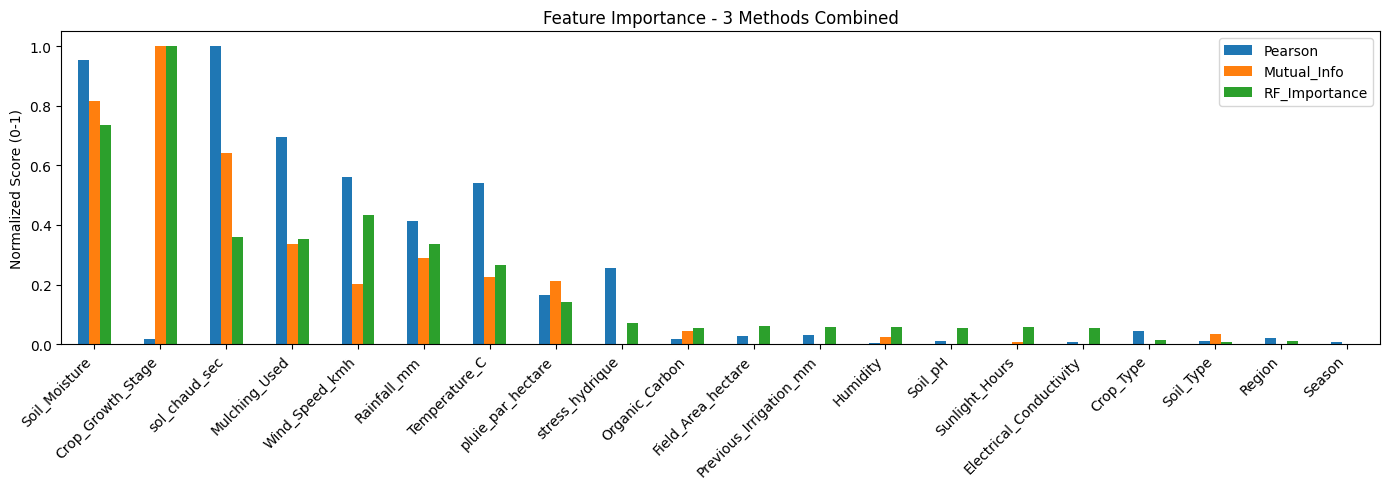

In [8]:

train_df = pd.read_csv('../../../data/sensor_data/train.csv')
test_df= pd.read_csv('../../../data/sensor_data/test.csv')

TARGET = 'besoin_eau'
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

# --- 1. Pearson Correlation ---
pearson = X.corrwith(y).abs().rename('Pearson')

# --- 2. Mutual Information ---
mi = mutual_info_classif(X, y, random_state=42)
mi = pd.Series(mi, index=X.columns, name='Mutual_Info')

# --- 3. Random Forest Importance ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=X.columns, name='RF_Importance')

# --- Combine ---
results = pd.concat([pearson, mi, rf_imp], axis=1)

# Normalize each method to 0-1 for fair comparison
results_norm = results.apply(lambda x: (x - x.min()) / (x.max() - x.min()))
results_norm['Average'] = results_norm.mean(axis=1)
results_norm = results_norm.sort_values('Average', ascending=False)

print(results_norm.round(3))

# Plot
results_norm.drop(columns='Average').plot(kind='bar', figsize=(14, 5))
plt.title('Feature Importance - 3 Methods Combined')
plt.ylabel('Normalized Score (0-1)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### **2. Feature Selection: Strong features (Average > 0.3)**
* **0.3 was chosen because it falls right in that natural gap between the clearly useful features and the weak ones**

In [9]:
selected_features=results_norm[results_norm['Average']>0.3].index.tolist()

train_df_selected=train_df[selected_features+[TARGET]]
test_df_selected=test_df[selected_features+[TARGET]]
print(train_df_selected.head(3))

   Soil_Moisture  Crop_Growth_Stage  sol_chaud_sec  Mulching_Used  \
0           8.78                  2      25.505112              1   
1          61.71                  3      10.518263              0   
2          26.18                  3      10.600552              0   

   Wind_Speed_kmh  Rainfall_mm  Temperature_C  besoin_eau  
0           12.87      2423.51          27.96           0  
1           19.40      1930.96          27.47           1  
2            5.32      2234.30          14.36           0  


🚨**After we entrain the model we saw that the model does a lot of overfitting, Because we used feature that were calculated from other features => Now we will keep only the original features**

In [10]:
"""
selected_features = [
    'Soil_Moisture',
    'Crop_Growth_Stage',
    'Mulching_Used',
    'Wind_Speed_kmh',
    'Rainfall_mm',
    'Temperature_C'
]


train_df_selected=train_df[selected_features+[TARGET]]
test_df_selected=test_df[selected_features+[TARGET]]"""


"\nselected_features = [\n    'Soil_Moisture',\n    'Crop_Growth_Stage',\n    'Mulching_Used',\n    'Wind_Speed_kmh',\n    'Rainfall_mm',\n    'Temperature_C'\n]\n\n\ntrain_df_selected=train_df[selected_features+[TARGET]]\ntest_df_selected=test_df[selected_features+[TARGET]]"

In [11]:
print(train_df_selected)

      Soil_Moisture  Crop_Growth_Stage  sol_chaud_sec  Mulching_Used  \
0              8.78                  2      25.505112              1   
1             61.71                  3      10.518263              0   
2             26.18                  3      10.600552              0   
3             38.28                  1      12.220560              0   
4             22.94                  0      27.441066              0   
...             ...                ...            ...            ...   
7995          52.43                  1      13.562207              0   
7996          40.14                  3      23.105960              1   
7997          62.86                  0       7.628556              1   
7998          62.34                  2       6.921908              0   
7999          34.76                  3      26.370008              0   

      Wind_Speed_kmh  Rainfall_mm  Temperature_C  besoin_eau  
0              12.87      2423.51          27.96           0  
1        

##### **3. Handle class imbalance "besoin_eau" : 0-4691 , 1-3309 with SMOTE**

In [12]:
# calcule the ration of the two classes in the target variable

print(train_df_selected['besoin_eau'].value_counts())
print(f"\nImbalance ratio: {train_df_selected['besoin_eau'].value_counts()[0] / train_df_selected['besoin_eau'].value_counts()[1]:.2f}")


besoin_eau
0    4691
1    3309
Name: count, dtype: int64

Imbalance ratio: 1.42


In [13]:
from imblearn.over_sampling import SMOTE

TARGET = 'besoin_eau'

X_train = train_df_selected.drop(columns=[TARGET])
y_train = train_df_selected[TARGET]

X_test = test_df_selected.drop(columns=[TARGET])
y_test = test_df_selected[TARGET]

print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
besoin_eau
0    4691
1    3309
Name: count, dtype: int64

After SMOTE:
besoin_eau
0    4691
1    4691
Name: count, dtype: int64


##### **SMOTE adds synthetic rows for the minority class (class 1)**
*-> How SMOTE works step by step:*
* Takes a random sample from class 1
* Finds its K nearest neighbors (other class 1 samples close to it)
* Creates a new synthetic point somewhere between them

##### **4. Scaling / Normalization the data**

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on train, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled  = scaler.transform(X_test)

print('Before scaling (X_train first row):')
print(X_train_resampled.iloc[0].values)

print('\nAfter scaling (X_train first row):')
print(X_train_scaled[0])

Before scaling (X_train first row):
[8.7800000e+00 2.0000000e+00 2.5505112e+01 1.0000000e+00 1.2870000e+01
 2.4235100e+03 2.7960000e+01]

After scaling (X_train first row):
[-1.64904706  0.49434162  1.08961774  1.11100923  0.44241623  1.64189588
  0.06537899]


##### **5. MLP implementation**

In [15]:
import yaml

with open("../params_config.yaml", "r") as f:
    config = yaml.safe_load(f)

mlp = config["models"]["mlp"]

hidden_layers    = mlp["hidden_layers"]       # [32, 16, 8]
activation       = mlp["activation"]          # "relu"
output_activation= mlp["output_activation"]   # "sigmoid"
dropout_rates    = mlp["dropout_rates"]       # [0.4, 0.3, 0.2]
batch_norm       = mlp["batch_normalization"] # True


optimizer        = mlp["optimizer"]           # "adam"
loss             = mlp["loss"]                # "binary_crossentropy"
epochs           = mlp["epochs"]              # 100
batch_size       = mlp["batch_size"]          # 32
validation_split = mlp["validation_split"]    # 0.2

es_monitor       = mlp["early_stopping"]["monitor"]   # "val_loss"
es_patience      = mlp["early_stopping"]["patience"]  # 10


threshold        = mlp["threshold"]           # 0.40

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


model= Sequential([
    Dense(32,activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(8,activation='relu'),
    Dropout(0.2),
    Dense(1,activation='sigmoid')
])


In [17]:
model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

##### **model.compile() tells the model how to learn before training starts. It sets 3 things:**

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                256       
                                                                 
 batch_normalization (Batch  (None, 32)                128       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 batch_normalization_1 (Bat  (None, 16)                64        
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 16)                0

##### **What is model.summary()?**
It shows the blueprint of the perceptron — the structure and number of parameters. At this stage the model knows nothing yet, all weights are randomly initialized.

**params_of_layer = (inputs × neurons) + neurons(biases of each neurons)**


In [ ]:
early_stopping= EarlyStopping(
    monitor=es_monitor,
    patience=es_patience,
    restore_best_weights=True
)


history=model.fit(
    X_train_scaled, y_train_resampled,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=validation_split,
    callbacks=[early_stopping],
    verbose=1
)

'\nhistory=model.fit(\n    X_train_scaled, y_train_resampled,\n    epochs=epochs,\n    batch_size=batch_size,\n    validation_split=validation_split,\n    callbacks=[early_stopping],\n    verbose=1\n)'

**Load the model so to not retrain it**

In [20]:
import subprocess
subprocess.run(["pip", "install", "dagshub"])

CompletedProcess(args=['pip', 'install', 'dagshub'], returncode=1)

In [33]:
import mlflow
import dagshub
from dotenv import load_dotenv
import os
from pathlib import Path
import tensorflow as tf



In [ ]:
load_dotenv(dotenv_path=Path('E:/Smart-Irrigation-Project/mlflow_setup/.env'))

dagshub_username=os.getenv("DAGSHUB_USERNAME")
dagshub_repo_name=os.getenv("DAGSHUB_REPO_NAME")

dagshub.init(
    repo_owner=dagshub_username,    # your DagsHub username
    repo_name=dagshub_repo_name,    # your repo name
    mlflow=True
)

loaded_model = mlflow.keras.load_model("models:/mlp_model/1")
print(loaded_model.summary())



Initialized MLflow to track repo "Saadiaboussiar/Smart-Irrigation-Project"

Repository Saadiaboussiar/Smart-Irrigation-Project initialized!

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                256       
                                                                 
 batch_normalization (Batch  (None, 32)                128       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 batch_normalization_1 (Bat  (None, 16)                64        
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 16)                0

##### **EarlyStopping Summary**
-> What it is: A callback that automatically stops training when the model stops improving — to prevent overfitting.

* **monitor='val_loss'**: Watches validation loss after each epoch
* **patience=10** : Waits 10 epochs before stopping if no improvement
* **restore_best_weights=True**: Restores weights from the single best epoch (these weights are the best ones our model can use)

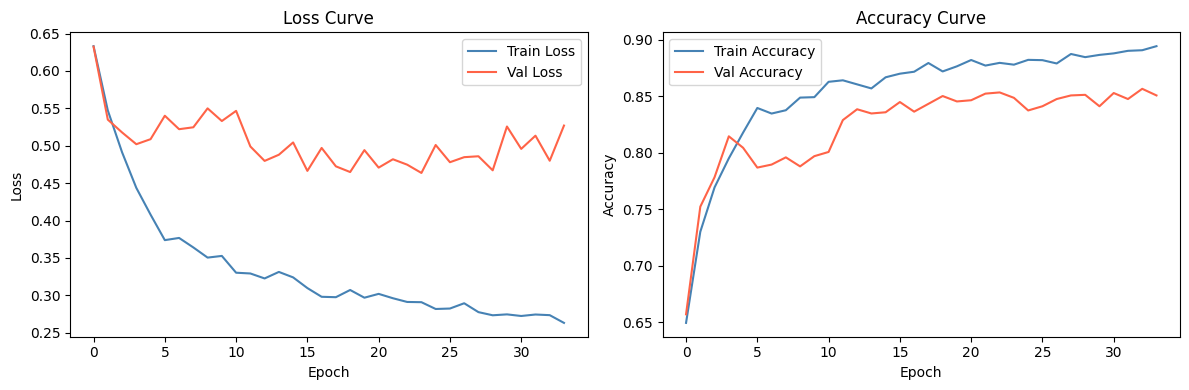

In [ ]:
plt.figure(figsize=(12, 4))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss', color='tomato')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

After training the model, it stopped in epoch 12 with  loss: 0.2205 - accuracy: 0.9070 - val_loss: 0.5031 - val_accuracy: 0.8482
--> We can see a red flag  🚨: 
* Training loss=0.2 
* validation loss=0.5 
=> A big gap between the two === **OVERFITTING**
* Solution: 
    * We will try t dropout more neurons in the perceptron. => **[Didnt work]**
    * We will try to simplify the perceptron ( reduce the number of neurons in each layer) => **[Didnt work]**
    * We noticed that some used feature are calculated from other features, so no we will only use the original features. => **[Didnt work]**
    * Lets just move and see the loss for test data



In [35]:
loss, accuracy= model.evaluate(X_test_scaled,y_test, verbose=0)
print(f'Test Loss:     {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')



Test Loss:     0.2028
Test Accuracy: 0.9160


**=> We got an excellent result**
- So there was no real overfitting — it was a false alarm caused by SMOTE synthetic samples being in the validation split. ✅
- No need to remove "soil_chaud_sec" from selected features array

##### **6. Model Evalution:**

In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import seaborn as sns

In [37]:
y_pred_prob= model.predict(X_test_scaled)

# Try different thresholds
thresholds = [0.5, 0.45, 0.40, 0.35, 0.30]

for thresh in thresholds:
    y_pred_thresh = (y_pred_prob > thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp)
    print(f"Threshold={thresh:.2f} → FN={fn}, FP={fp}, Recall={recall:.3f}, Precision={precision:.3f}")


63/63 [==============================] - 0s 2ms/step
Threshold=0.50 → FN=76, FP=92, Recall=0.908, Precision=0.891
Threshold=0.45 → FN=57, FP=120, Recall=0.931, Precision=0.865
Threshold=0.40 → FN=45, FP=145, Recall=0.946, Precision=0.844
Threshold=0.35 → FN=32, FP=167, Recall=0.961, Precision=0.826
Threshold=0.30 → FN=28, FP=188, Recall=0.966, Precision=0.810


In [40]:
y_pred=(y_pred_prob > threshold).astype(int)
print("Classification Report:")
report = classification_report(y_test, y_pred, target_names=['No water', 'Needs water'], output_dict=True)
print(report)

Classification Report:
{'No water': {'precision': 0.9580615097856477, 'recall': 0.876385336743393, 'f1-score': 0.9154051647373108, 'support': 1173.0}, 'Needs water': {'precision': 0.8435814455231931, 'recall': 0.9455864570737605, 'f1-score': 0.8916761687571265, 'support': 827.0}, 'accuracy': 0.905, 'macro avg': {'precision': 0.9008214776544204, 'recall': 0.9109858969085768, 'f1-score': 0.9035406667472187, 'support': 2000.0}, 'weighted avg': {'precision': 0.9107240032131229, 'recall': 0.905, 'f1-score': 0.9055932248995046, 'support': 2000.0}}


In [41]:
no_water_precision   = report['No water']['precision']
no_water_recall      = report['No water']['recall']
no_water_f1          = report['No water']['f1-score']

needs_water_precision = report['Needs water']['precision']
needs_water_recall    = report['Needs water']['recall']
needs_water_f1        = report['Needs water']['f1-score']

# overall
accuracy = report['accuracy']

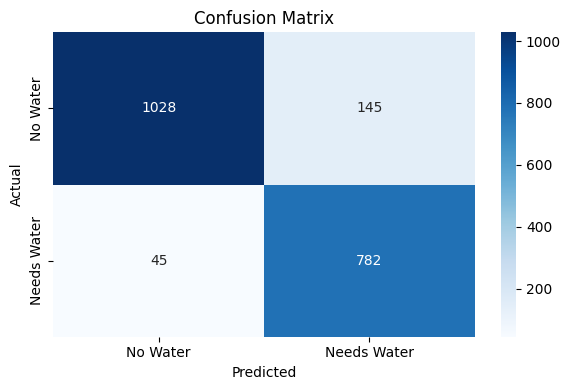

In [42]:
plt.figure(figsize=(6,4))

cm=confusion_matrix(y_test,y_pred)

TN, FP, FN, TP = cm.ravel()

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Water', 'Needs Water'],
    yticklabels=['No Water', 'Needs Water']
)

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**The most critical error for irrigation is False Negative (FN = 56):**
* 56 plants that NEEDED water → model said "no water" ❌
→ those plants could be damaged in real life 🌱
* Solution:
    * Instead of 0.5, use a lower value so the model is more "sensitive" to predicting "needs water" , we will try an array of thresholds
**=> We found that the best thresholds is 0.4**

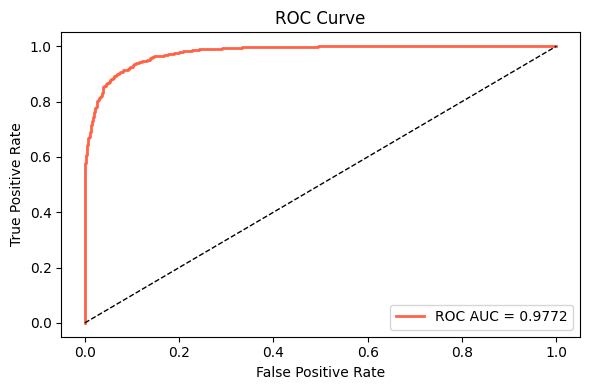

In [43]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

**So ROC answers this question:**
"At any threshold I choose, how good is the model at distinguishing thirsty plants from non-thirsty ones?

##### **7. Save everything to Local first**

In [44]:

import joblib
import json

In [ ]:
# 1. Save scaler
model.save('./mlp_model.keras')

# 2. Save scaler
joblib.dump(scaler, './mlp_scaler.pkl')

# 3. Save config
model_config = {
    'threshold': 0.40,
    'selected_features': selected_features,
    'scaler': 'mlp_scaler.pkl'
}

with open('./mlp_model_config.json', 'w') as f:
    json.dump(model_config, f, indent=4)

print('✅ mlp_model.keras saved')
print('✅ scaler.pkl saved')
print('✅ model_config.json saved')

✅ mlp_model.keras saved
✅ scaler.pkl saved
✅ model_config.json saved


##### **8. Save everything to MLflow**

In [45]:
import mlflow
import mlflow.keras
from dotenv import load_dotenv
import os
from pathlib import Path

In [80]:
load_dotenv(dotenv_path=Path('E:/Smart-Irrigation-Project/mlflow_setup/.env'))



example_input = X_train_scaled[:5]

dagshub_username=os.getenv("DAGSHUB_USERNAME")
dagshub_repo_name=os.getenv("DAGSHUB_REPO_NAME")

os.environ["MLFLOW_TRACKING_USERNAME"] = dagshub_username
os.environ["MLFLOW_TRACKING_PASSWORD"] = os.getenv("DAGSHUB_USER_TOKEN")

mlflow.set_tracking_uri("https://dagshub.com/"+dagshub_username+"/"+dagshub_repo_name+".mlflow")

mlflow.set_experiment(os.getenv("MLFLOW_EXPERIMENT_NAME"))

with mlflow.start_run(run_name="mlp_v1"):

    # 1. Log parameters
    mlflow.log_param("model_type","MLP"),
    mlflow.log_param("hidden_layers","32-16"),
    mlflow.log_param("optimizer",optimizer),
    mlflow.log_param("batch_size",batch_size),
    mlflow.log_param("threshold",threshold),
    mlflow.log_param("selected_features",selected_features),
    mlflow.log_param("smote",True),
    mlflow.log_param("scaler","StandarScaler")

    # 2. Log metrics
    mlflow.log_metric("accuracy",accuracy),
    mlflow.log_metric("recall_needs_water",needs_water_recall),
    mlflow.log_metric("precision_needs_water",needs_water_precision),
    mlflow.log_metric("needs_water_f1", needs_water_f1)
    mlflow.log_metric("no_water_precision", no_water_precision)
    mlflow.log_metric("no_water_recall", no_water_recall)

    mlflow.log_metric("roc_auc",roc_auc),
    mlflow.log_metric("TP", TP)
    mlflow.log_metric("TN", TN)
    mlflow.log_metric("FP", FP)
    mlflow.log_metric("FN", FN)


    
    # 3. Log model
    mlflow.keras.log_model(
        model,
        artifact_path="mlp_model",
        registered_model_name="mlp_model"
    )
    
    # 4. Log scaler
    mlflow.log_artifact("./mlp_scaler.pkl")

    # 5. Log config
    mlflow.log_artifact('./mlp_model_config.json')

    print("✅ Everything logged to DagsHub MLflow!")



2026/05/08 11:39:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 11:39:46 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


INFO:tensorflow:Assets written to: C:\Users\LENOVO~1\AppData\Local\Temp\tmpazdpjjtl\model\data\model\assets


INFO:tensorflow:Assets written to: C:\Users\LENOVO~1\AppData\Local\Temp\tmpazdpjjtl\model\data\model\assets
Registered model 'mlp_model' already exists. Creating a new version of this model...
2026/05/08 11:40:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: mlp_model, version 2
Created version '2' of model 'mlp_model'.


✅ Everything logged to DagsHub MLflow!
🏃 View run mlp_v1 at: https://dagshub.com/Saadiaboussiar/Smart-Irrigation-Project.mlflow/#/experiments/0/runs/74f8a197414e44c1af1e3d9cf4539a68
🧪 View experiment at: https://dagshub.com/Saadiaboussiar/Smart-Irrigation-Project.mlflow/#/experiments/0
